In [2]:
import sys
from pathlib import Path
import pandas as pd

# Let notebook import project modules regardless of launch folder.
sys.path.append("..")

from src.shap_report import (
    load_base_model, compute_shap_values, global_importance_table,
    top_drivers_with_direction, plot_global_importance_bar,
    plot_summary_beeswarm, plot_dependence, write_driver_report,
 )

def find_project_root(start: Path) -> Path:
    """Walk upward until a folder containing both src/ and data/processed is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "data" / "processed").exists():
            return candidate
    raise FileNotFoundError(f"Could not locate project root from start={start}")

def normalize_encoded_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Match common OHE naming variants (spaces/slashes) across pipeline versions."""
    out = df.copy()
    out.columns = [c.replace(" ", "_").replace("/", "_") for c in out.columns]
    return out

ROOT = find_project_root(Path.cwd().resolve())
DATA_DIR = ROOT / "data" / "processed"
MODEL_DIR = ROOT / "models"
REPORT_DIR = ROOT / "reports"
FIG_DIR = REPORT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

X_train_path = DATA_DIR / "X_train_encoded.csv"
X_test_path = DATA_DIR / "X_test_encoded.csv"
if not X_train_path.exists() or not X_test_path.exists():
    raise FileNotFoundError(
        f"Missing encoded files. Expected:\n- {X_train_path}\n- {X_test_path}"
    )

X_train = normalize_encoded_columns(pd.read_csv(X_train_path))
X_test = normalize_encoded_columns(pd.read_csv(X_test_path))

model = load_base_model(MODEL_DIR)

# Align feature schema exactly to the model's training columns.
if hasattr(model, "feature_name_") and model.feature_name_:
    model_cols = list(model.feature_name_)
    missing_cols = [c for c in model_cols if c not in X_test.columns]
    extra_cols = [c for c in X_test.columns if c not in model_cols]
    if missing_cols or extra_cols:
        raise ValueError(
            "Encoded feature schema does not match model schema. "
            f"Missing: {missing_cols} | Extra: {extra_cols}"
        )
    X_train = X_train.reindex(columns=model_cols)
    X_test = X_test.reindex(columns=model_cols)

print(f"ROOT: {ROOT}")
print(f"Loaded {type(model).__name__} with {X_test.shape[1]} features")

ROOT: /home/yon/churn_project
Loaded LGBMClassifier with 28 features


In [3]:
assert list(X_train.columns) == list(X_test.columns), "train/test column mismatch"
assert list(X_test.columns) == list(model.feature_name_) if hasattr(model, "feature_name_") else True, \
    "model was trained on different columns than X_test — check Phase 3 handoff"

print(f"X_test shape: {X_test.shape}")
print(f"Columns: {list(X_test.columns)}")

X_test shape: (1409, 28)
Columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'InternetService_DSL', 'InternetService_Fiber_optic', 'InternetService_No', 'MultipleLines_No', 'MultipleLines_Yes', 'PaymentMethod_Bank_transfer_(automatic)', 'PaymentMethod_Credit_card_(automatic)', 'PaymentMethod_Electronic_check', 'PaymentMethod_Mailed_check', 'tenure', 'MonthlyCharges', 'charges_per_month', 'cost_per_service', 'SeniorCitizen', 'num_services', 'is_senior_with_no_support']


In [4]:
explainer, shap_values, expected_value = compute_shap_values(model, X_test)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Base rate (expected value): {expected_value:.4f}")

SHAP values shape: (1409, 28)
Base rate (expected value): -1.6289


/home/yon/churn_project/venv/lib/python3.14/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [5]:
importance_df = global_importance_table(shap_values, X_test)
print(importance_df.head(15).to_string(index=False))

                       feature  mean_abs_shap
                      Contract       0.782071
                        tenure       0.505919
   InternetService_Fiber_optic       0.247907
PaymentMethod_Electronic_check       0.183727
            InternetService_No       0.152151
             charges_per_month       0.125460
              PaperlessBilling       0.122603
                OnlineSecurity       0.104981
                MonthlyCharges       0.102944
               StreamingMovies       0.100249
              cost_per_service       0.077954
                   TechSupport       0.070668
              MultipleLines_No       0.057964
                   StreamingTV       0.055995
                    Dependents       0.050089


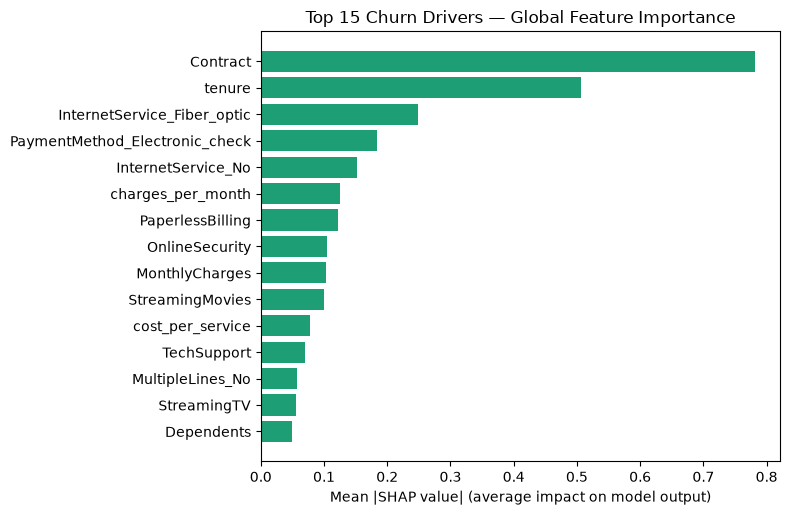

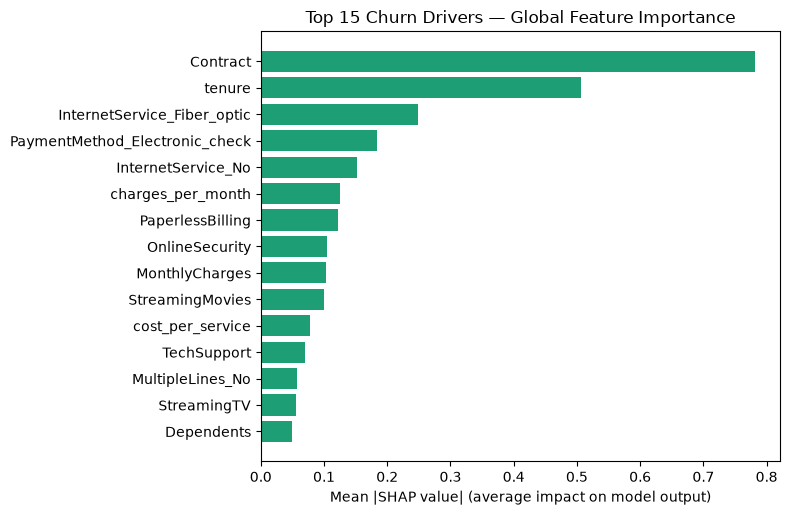

In [6]:
fig1 = plot_global_importance_bar(importance_df, top_n=15,
                                    out_path=FIG_DIR / "shap_global_importance.png")
fig1

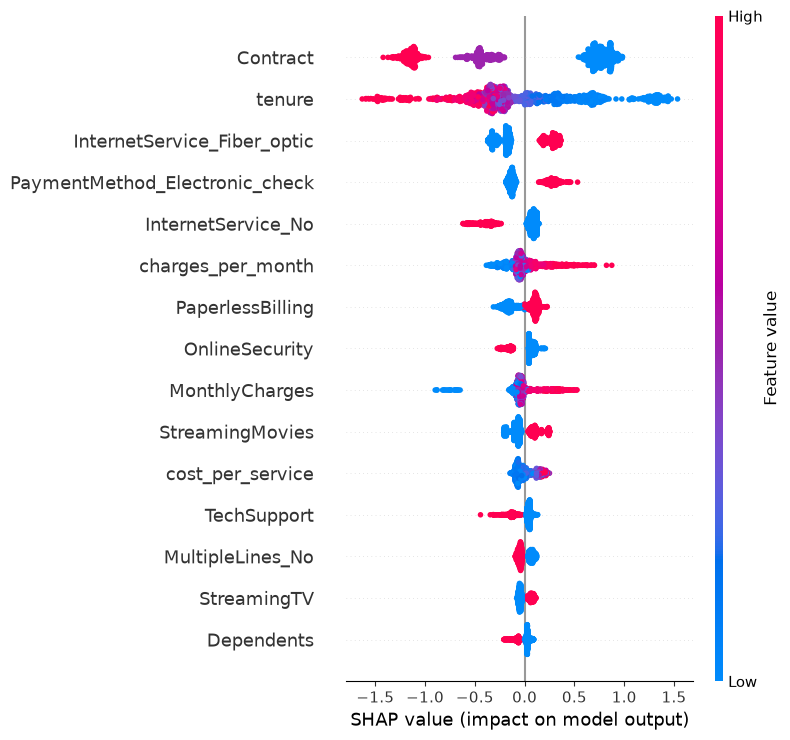

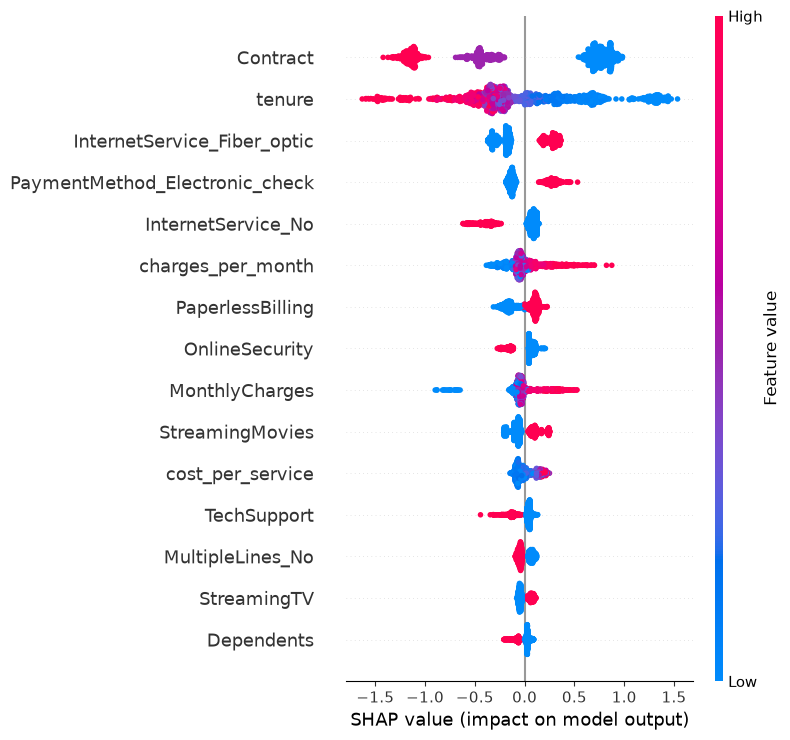

In [7]:
fig2 = plot_summary_beeswarm(shap_values, X_test, max_display=15,
                               out_path=FIG_DIR / "shap_summary_beeswarm.png")
fig2

In [8]:
top_drivers = top_drivers_with_direction(shap_values, X_test, top_n=10)
print(top_drivers.to_string(index=False))

                       feature  mean_abs_shap  mean_signed_shap            direction
                      Contract       0.782071          0.057517 increases churn risk
                        tenure       0.505919         -0.012763 decreases churn risk
   InternetService_Fiber_optic       0.247907         -0.012681 decreases churn risk
PaymentMethod_Electronic_check       0.183727          0.005970 increases churn risk
            InternetService_No       0.152151         -0.024608 decreases churn risk
             charges_per_month       0.125460          0.001144 increases churn risk
              PaperlessBilling       0.122603         -0.003621 decreases churn risk
                OnlineSecurity       0.104981          0.009597 increases churn risk
                MonthlyCharges       0.102944         -0.001236 decreases churn risk
               StreamingMovies       0.100249         -0.013011 decreases churn risk


Generating dependence plots for: ['Contract', 'tenure', 'InternetService_Fiber_optic']


<Figure size 700x500 with 0 Axes>

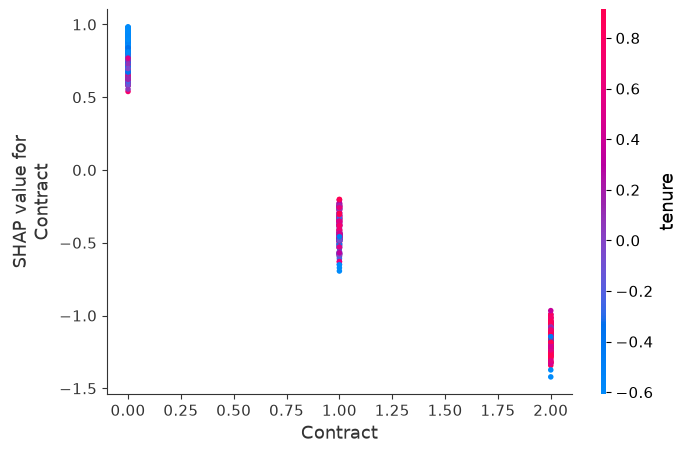

<Figure size 700x500 with 0 Axes>

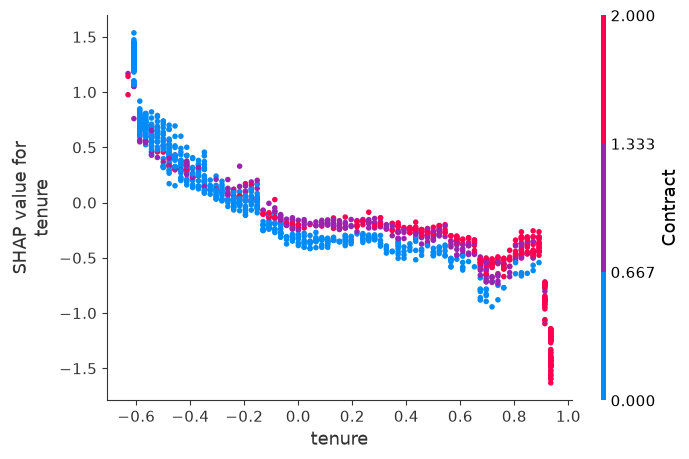

<Figure size 700x500 with 0 Axes>

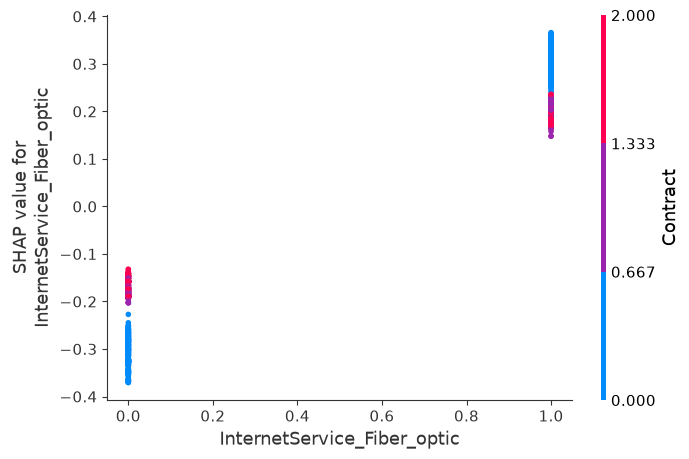

In [9]:
top_3_features = importance_df["feature"].head(3).tolist()
print(f"Generating dependence plots for: {top_3_features}")

for feat in top_3_features:
    safe_name = feat.replace(" ", "_").replace("/", "_")
    fig = plot_dependence(feat, shap_values, X_test,
                           out_path=FIG_DIR / f"shap_dependence_{safe_name}.png")

In [10]:
model_context = (
    "**Model explained:** LightGBM (pre-calibration base model, `lgbm_base_tuned.pkl`).\n\n"
    "**Production model:** Platt-calibrated LightGBM (`lgbm_calibrated_sigmoid.pkl`), "
    "Brier Score Loss 0.1351 on held-out test set (gate: < 0.14, PASSED)."
)

report_path = write_driver_report(top_drivers, REPORT_DIR, model_context=model_context)
print(f"Saved {report_path}")

Saved /home/yon/churn_project/reports/shap_churn_driver_report.md


In [11]:
print("=== Phase 4 Checkpoint ===")
print(f"Top driver: {top_drivers.iloc[0]['feature']} "
      f"({top_drivers.iloc[0]['direction']}, mean |SHAP| = {top_drivers.iloc[0]['mean_abs_shap']:.4f})")
print()
print("Files written:")
print("  - reports/shap_churn_driver_report.md")
print("  - reports/figures/shap_global_importance.png")
print("  - reports/figures/shap_summary_beeswarm.png")
print("  - reports/figures/shap_dependence_<feature>.png  (top 3)")
print()
print("Next: review shap_churn_driver_report.md for business sense,")
print("git commit Phase 4, hand off to Member 5 (budget sim + model card).")

=== Phase 4 Checkpoint ===
Top driver: Contract (increases churn risk, mean |SHAP| = 0.7821)

Files written:
  - reports/shap_churn_driver_report.md
  - reports/figures/shap_global_importance.png
  - reports/figures/shap_summary_beeswarm.png
  - reports/figures/shap_dependence_<feature>.png  (top 3)

Next: review shap_churn_driver_report.md for business sense,
git commit Phase 4, hand off to Member 5 (budget sim + model card).
